# LSTM-Based Time-Series Forecasting

**Assignment:** Develop an LSTM-based model for time-series forecasting.

**Dataset:** Apple (AAPL) historical stock prices  
**Target:** Closing Price  
**Sequence Length:** Previous 60 trading days  
**Train/Test Split:** 80% / 20%  
**Evaluation Metrics:** MAE and RMSE

In [1]:
!pip install yfinance -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import math

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Download the Dataset

In [3]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

print("Dataset shape:", data.shape)
display(data.head())

[*********************100%***********************]  1 of 1 completed

Dataset shape: (2766, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171753,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490795,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493017,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822437,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


## 2. Explore the Dataset

In [4]:
print("Dataset Information:")
data.info()

print("\nStatistical Summary:")
display(data.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2766 non-null   float64
 1   (Close, AAPL)      2766 non-null   float64
 2   (High, AAPL)       2766 non-null   float64
 3   (Low, AAPL)        2766 non-null   float64
 4   (Open, AAPL)       2766 non-null   float64
 5   (Volume, AAPL)     2766 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 151.3 KB

Statistical Summary:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03
mean,106.036035,108.644931,109.721494,107.462519,108.546994,1.113994e+08
std,74.119445,73.856228,74.561122,73.072339,73.777601,6.804243e+07
min,20.548140,22.584999,22.917500,22.367500,22.500000,1.791060e+07
25%,36.551956,39.080626,39.460626,38.765626,39.160000,6.488962e+07
50%,88.231117,91.204998,92.407501,90.283749,91.176250,9.454380e+07
75%,168.189369,170.830006,172.634998,169.352497,170.955002,1.372937e+08
max,285.413116,286.190002,288.619995,283.299988,286.200012,6.488252e+08


## 3. Select the Closing Price

In [5]:
close_data = data[['Close']].copy()

# Handle MultiIndex columns returned by some yfinance versions
if isinstance(close_data.columns, pd.MultiIndex):
    close_data.columns = close_data.columns.get_level_values(0)

close_data = close_data.dropna()

print("Number of records:", len(close_data))
display(close_data.head())

Number of records: 2766


Price,Close
Date,
2015-01-02,27.332500
2015-01-05,26.562500
2015-01-06,26.565001
2015-01-07,26.937500
2015-01-08,27.972500


## 4. Visualize Historical Closing Price

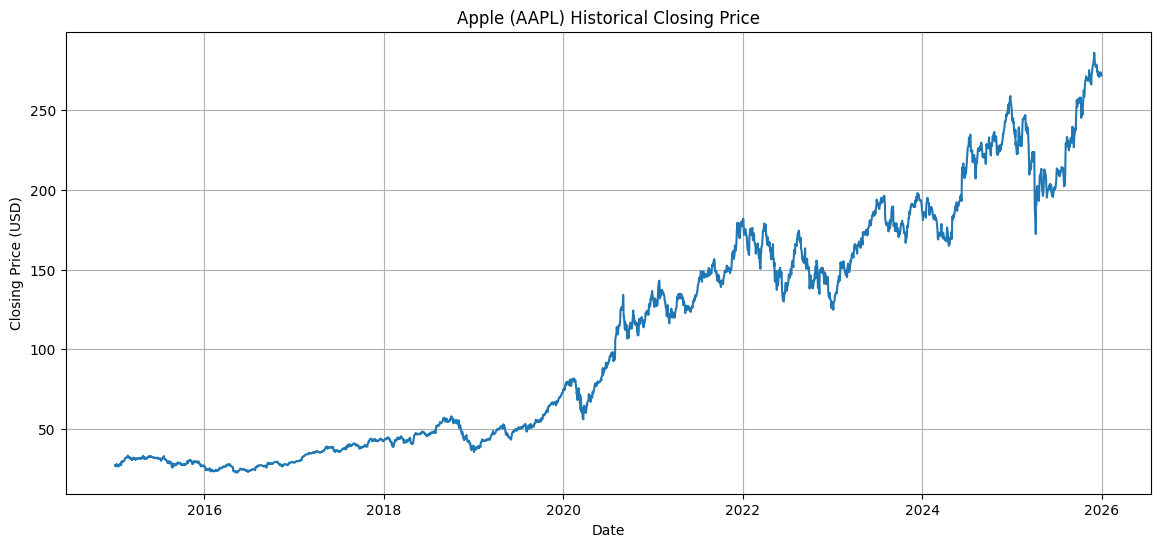

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(close_data.index, close_data["Close"])
plt.title("Apple (AAPL) Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.show()

## 5. Normalize the Data

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_data)

print("Original minimum price:", close_data["Close"].min())
print("Original maximum price:", close_data["Close"].max())
print("\nFirst 10 scaled values:")
print(scaled_data[:10].flatten())

Original minimum price: 22.584999084472656
Original maximum price: 286.19000244140625

First 10 scaled values:
[0.01800991 0.01508887 0.01509835 0.01651145 0.02043778 0.02055159
 0.01793403 0.01885397 0.01845565 0.01562945]


## 6. Train-Test Split

In [8]:
train_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Total records:", len(scaled_data))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

Total records: 2766
Training records: 2212
Testing records: 554


## 7. Create Time-Series Sequences

The model uses the previous **60 trading days** to predict the next day's closing price.

In [9]:
time_step = 60

def create_sequences(dataset, time_step):
    X, y = [], []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, time_step)
X_test, y_test = create_sequences(test_data, time_step)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2152, 60)
y_train shape: (2152,)
X_test shape: (494, 60)
y_test shape: (494,)


## 8. Reshape Data for LSTM

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Final X_train shape: (2152, 60, 1)
Final X_test shape: (494, 60, 1)


## 9. Build the LSTM Model

In [11]:
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Train the Model

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 0.0040 - val_loss: 5.8899e-04
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 7.4777e-04 - val_loss: 4.2633e-04
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 6.1834e-04 - val_loss: 6.9213e-04
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 5.5459e-04 - val_loss: 4.3200e-04
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 4.6027e-04 - val_loss: 0.0013
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 5.9827e-04 - val_loss: 8.2995e-04
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 4.1488e-04 - val_loss: 6.9573e-04
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 4.2989e-04 - val_loss: 3.3240e-04
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 4.6492e-04 - val_loss: 4.0874e-04
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 3.6004e-04 - val_loss: 3.4656e-04
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 3.7114e-04 - val

## 11. Plot Training and Validation Loss

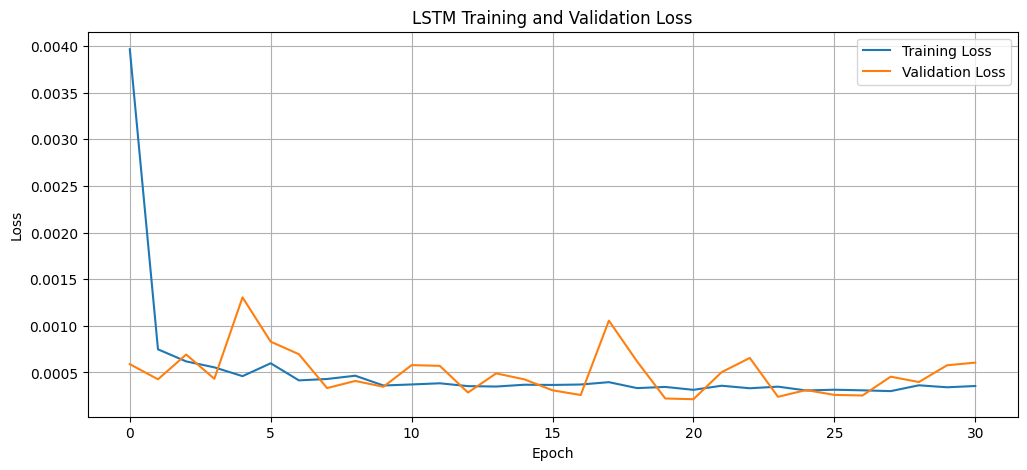

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Make Predictions

In [14]:
predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Prediction shape: (494, 1)


## 13. Convert Predictions Back to Original Prices

In [15]:
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("First 10 Actual Prices:")
print(actual_prices[:10].flatten())

print("\nFirst 10 Predicted Prices:")
print(predicted_prices[:10].flatten())

First 10 Actual Prices:
[185.91999817 183.63000488 182.67999268 188.63000488 191.55999756
 193.88999939 195.17999268 194.5        194.16999817 192.41999817]

First 10 Predicted Prices:
[184.13307 184.2985  184.26033 184.01445 184.41252 185.44786 186.9764
 188.73654 190.32246 191.58458]


## 14. Evaluate the Model

In [16]:
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = math.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("Model Evaluation")
print("---------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Evaluation
---------------------------
Mean Absolute Error (MAE): 5.6683
Root Mean Squared Error (RMSE): 7.2978


## 15. Actual vs Predicted Prices

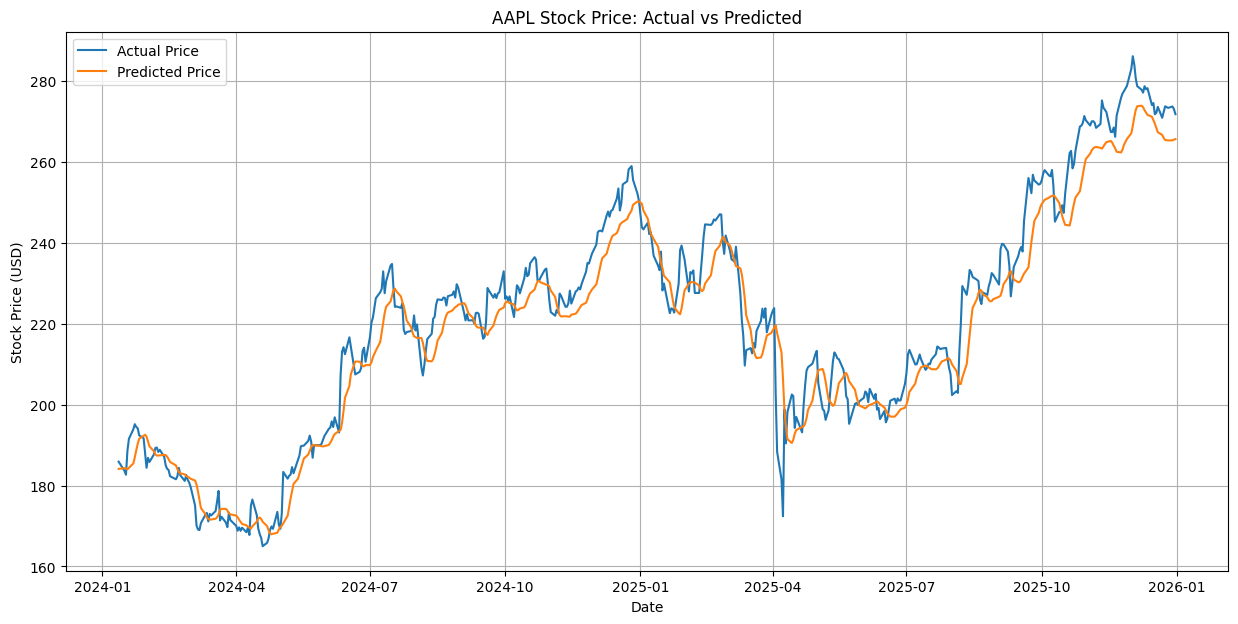

In [17]:
test_dates = close_data.index[train_size + time_step:]

plt.figure(figsize=(15, 7))
plt.plot(test_dates, actual_prices.flatten(), label="Actual Price")
plt.plot(test_dates, predicted_prices.flatten(), label="Predicted Price")
plt.title("AAPL Stock Price: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

## 16. Compare Actual and Predicted Values

In [18]:
comparison = pd.DataFrame({
    "Date": test_dates,
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predicted_prices.flatten()
})

comparison["Error"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
)

comparison["Absolute Error"] = comparison["Error"].abs()

display(comparison.head(20))

,Date,Actual Price,Predicted Price,Error,Absolute Error
0,2024-01-12,185.919998,184.133072,1.786926,1.786926
1,2024-01-16,183.630005,184.298492,-0.668488,0.668488
2,2024-01-17,182.679993,184.260330,-1.580338,1.580338
3,2024-01-18,188.630005,184.014450,4.615555,4.615555
4,2024-01-19,191.559998,184.412521,7.147476,7.147476
5,2024-01-22,193.889999,185.447861,8.442139,8.442139
6,2024-01-23,195.179993,186.976395,8.203598,8.203598
7,2024-01-24,194.500000,188.736542,5.763458,5.763458
8,2024-01-25,194.169998,190.322464,3.847534,3.847534
9,2024-01-26,192.419998,191.584579,0.835419,0.835419


## 17. Forecast the Next Trading Day

In [19]:
last_60_days = scaled_data[-time_step:]
X_future = last_60_days.reshape(1, time_step, 1)

next_day_scaled = model.predict(X_future)
next_day_price = scaler.inverse_transform(next_day_scaled)

print(
    "Predicted Next Trading Day Closing Price:",
    f"${float(next_day_price[0][0]):.2f}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Next Trading Day Closing Price: $265.63


## 18. Visualize the Next-Day Forecast

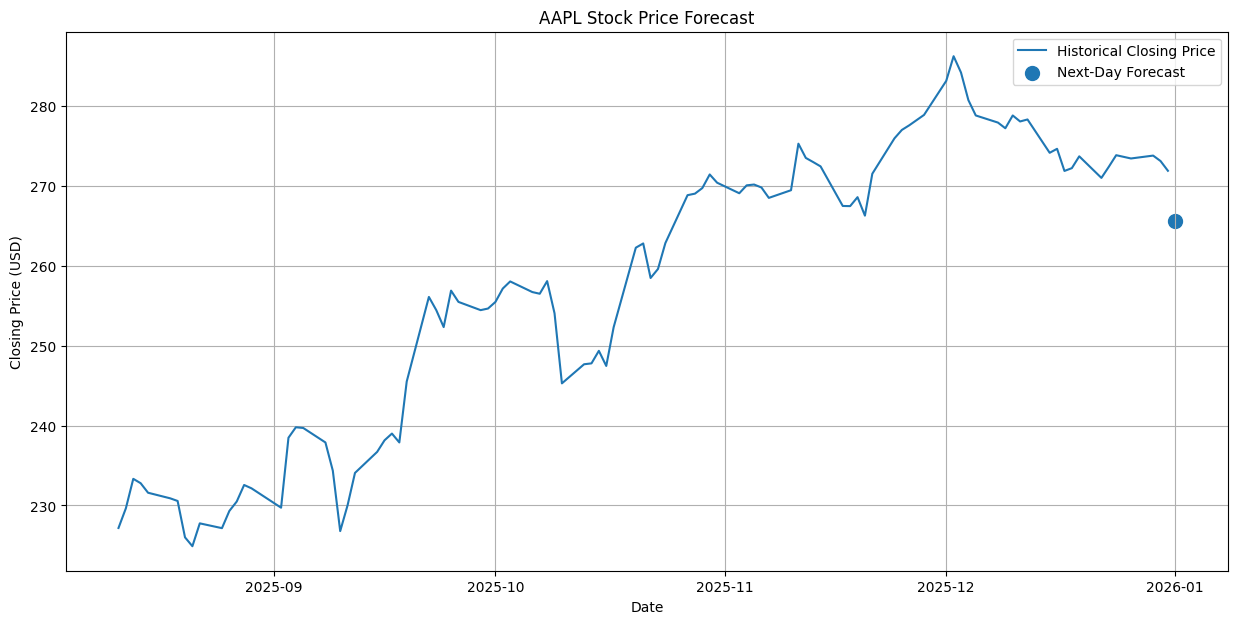

In [20]:
recent_days = 100

recent_dates = close_data.index[-recent_days:]
recent_prices = close_data["Close"].values[-recent_days:]

# Use the next calendar day only as a visualization point.
# The actual next trading day may differ because of weekends/holidays.
next_date = close_data.index[-1] + pd.Timedelta(days=1)

plt.figure(figsize=(15, 7))
plt.plot(
    recent_dates,
    recent_prices,
    label="Historical Closing Price"
)

plt.scatter(
    next_date,
    float(next_day_price[0][0]),
    label="Next-Day Forecast",
    s=100
)

plt.title("AAPL Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

## 19. Final Results

In [21]:
print("=" * 55)
print("LSTM TIME-SERIES FORECASTING RESULTS")
print("=" * 55)

print("\nDataset: Apple (AAPL) Historical Stock Prices")
print("Target Variable: Closing Price")
print("Sequence Length:", time_step)
print("Training Records:", len(train_data))
print("Testing Records:", len(test_data))

print("\nModel Architecture:")
print("LSTM Layer 1: 64 units")
print("Dropout: 20%")
print("LSTM Layer 2: 64 units")
print("Dropout: 20%")
print("Dense Layer: 32 units")
print("Output Layer: 1 unit")

print("\nEvaluation Metrics:")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

print("\nPredicted Next Trading Day Closing Price:")
print(f"${float(next_day_price[0][0]):.2f}")

print("=" * 55)

LSTM TIME-SERIES FORECASTING RESULTS

Dataset: Apple (AAPL) Historical Stock Prices
Target Variable: Closing Price
Sequence Length: 60
Training Records: 2212
Testing Records: 554

Model Architecture:
LSTM Layer 1: 64 units
Dropout: 20%
LSTM Layer 2: 64 units
Dropout: 20%
Dense Layer: 32 units
Output Layer: 1 unit

Evaluation Metrics:
MAE : 5.6683
RMSE: 7.2978

Predicted Next Trading Day Closing Price:
$265.63
